# Follow the Industry: Network Analysis

This notebook performs a full network analysis of the bipartite **Industry to Legislator** lobbying-contribution network built in `data_prep.ipynb`.

**Inputs** (produced by `data_prep.ipynb`):
- `lobbying_bipartite.gexf`     -> bipartite graph `B` (industries to legislators)
- `lobbying_legislators.gexf`   -> legislator-side projection `L`
- `lobbying_industries.gexf`    -> industry-side projection `I`

**Sections**
1. Network description & basic statistics
2. Degree distribution & scale-free analysis
3. Centrality & clustering
4. Community detection
5. Assortativity & attribute correlations
6. Spreading phenomena (SIS / SIR)


In [1]:
# Setup
%pip install -q networkx pandas matplotlib numpy scipy powerlaw

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import moment

from helpers import (
    get_average_degree, get_kmax, get_kmin,
    get_second_moment_of_degree, make_degree_histogram,
    size_of_giant_component, find_communities, draw_network,
)

np.random.seed(0)
plt.style.use('ggplot')

In [2]:
# Load graphs from data_prep.ipynb
B = nx.read_gexf("lobbying_bipartite.gexf")
L = nx.read_gexf("lobbying_legislators.gexf")
I = nx.read_gexf("lobbying_industries.gexf")

print(f"B (bipartite)   : {B.number_of_nodes():>5} nodes, {B.number_of_edges():>6} edges")
print(f"L (legislators) : {L.number_of_nodes():>5} nodes, {L.number_of_edges():>6} edges")
print(f"I (industries)  : {I.number_of_nodes():>5} nodes, {I.number_of_edges():>6} edges")

B (bipartite)   :  1875 nodes,  54991 edges
L (legislators) :   499 nodes,  63303 edges
I (industries)  :   226 nodes,  13469 edges


# 1. Network description

The lobbying contribution network is modeled as a **weighted, undirected, bipartite** graph `B = (V_I ∪ V_L, E)` where:

- `V_I` = industry sectors (from approx. 100 fine-grained CRP industry codes)
- `V_L` = U.S. federal legislators (House + Senate)
- An edge `(i, ℓ) ∈ E` exists iff industry `i` directed PAC contributions to legislator `ℓ` during the cycle, with `weight(i, ℓ)` = total dollars.

For analyses where a single-mode network is more informative we use the two projections `L` (legislator-side) and `I` (industry-side).

In [3]:
# Per-side bipartite degree statistics
ind_nodes = [n for n,d in B.nodes(data=True) if d['type']=='industry']
leg_nodes = [n for n,d in B.nodes(data=True) if d['type']=='legislator']

ind_degs = [B.degree(n) for n in ind_nodes]
leg_degs = [B.degree(n) for n in leg_nodes]

print("Bipartite graph B (degree by side):")
print(f"  Industries  ({len(ind_nodes):>3}):  <k> = {np.mean(ind_degs):6.2f}  "
      f"min = {min(ind_degs)}  max = {max(ind_degs)}")
print(f"  Legislators ({len(leg_nodes):>3}):  <k> = {np.mean(leg_degs):6.2f}  "
      f"min = {min(leg_degs)}  max = {max(leg_degs)}")


Bipartite graph B (degree by side):
  Industries  (390):  <k> = 141.00  min = 1  max = 576
  Legislators (1485):  <k> =  37.03  min = 1  max = 219


In [4]:
# Edge weight summary (contribution dollars)
weights = np.array([d['weight'] for _,_,d in B.edges(data=True)])
print(f"Edge-weight ($dollars) summary on B:")
print(f"  min:    ${weights.min():>14,.2f}")
print(f"  median: ${np.median(weights):>14,.2f}")
print(f"  mean:   ${weights.mean():>14,.2f}")
print(f"  max:    ${weights.max():>14,.2f}")
print(f"  total:  ${weights.sum():>14,.2f}")

Edge-weight ($dollars) summary on B:
  min:    $          2.00
  median: $      5,000.00
  mean:   $      9,029.07
  max:    $    537,600.00
  total:  $496,517,602.00


# 2. Degree distribution and scale-free analysis

> **Research question:** does the lobbying network exhibit a scale-free degree distribution (indicating a small number of dominant actors)?

I plotted the degree distribution `p_k` for the bipartite graph `B` (split by side) and for both projections `L` and `I`, then fit a power-law to the legislator-projection degrees using the `powerlaw` package and took note of the exponent `γ`.

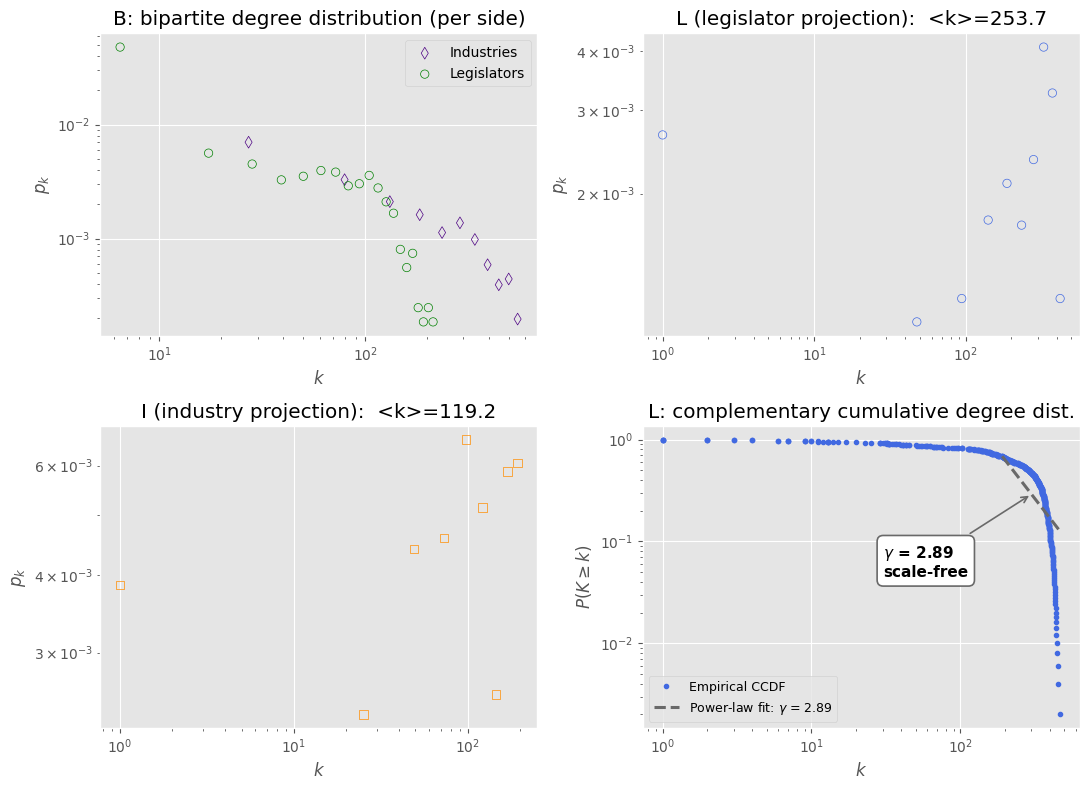

In [5]:
import powerlaw

# Pre-compute the power-law fit once (used in the CCDF panel below)
deg_L = np.array([d for _, d in L.degree() if d > 0])
fit = powerlaw.Fit(deg_L, discrete=True, verbose=False)
gamma = fit.alpha
xmin  = fit.xmin

# Degree distributions for B (each side), L, and I
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

def side_degree_hist(g, nodes, bins='auto'):
    degs = np.array([g.degree(n) for n in nodes])
    counts, edges = np.histogram(degs, bins=bins, density=True)
    k = 0.5*(edges[:-1]+edges[1:])
    mask = counts > 0
    return k[mask], counts[mask], degs

# (0,0) Bipartite per side
k_i, pk_i, _ = side_degree_hist(B, ind_nodes)
k_l, pk_l, _ = side_degree_hist(B, leg_nodes)
axes[0,0].scatter(k_i, pk_i, marker='d', edgecolors='indigo', facecolors='none', label='Industries')
axes[0,0].scatter(k_l, pk_l, marker='o', edgecolors='green',  facecolors='none', label='Legislators')
axes[0,0].set_xlabel('$k$'); axes[0,0].set_ylabel('$p_k$')
axes[0,0].set_title('B: bipartite degree distribution (per side)')
axes[0,0].set_xscale('log'); axes[0,0].set_yscale('log'); axes[0,0].legend()

# (0,1) L raw p_k
k, pk = make_degree_histogram(L, bins='auto')
axes[0,1].scatter(k, pk, marker='o', edgecolors='royalblue', facecolors='none')
axes[0,1].set_xlabel('$k$'); axes[0,1].set_ylabel('$p_k$')
axes[0,1].set_title(f'L (legislator projection):  <k>={get_average_degree(L):.1f}')
axes[0,1].set_xscale('log'); axes[0,1].set_yscale('log')

# (1,0) I projection
k, pk = make_degree_histogram(I, bins='auto')
axes[1,0].scatter(k, pk, marker='s', edgecolors='darkorange', facecolors='none')
axes[1,0].set_xlabel('$k$'); axes[1,0].set_ylabel('$p_k$')
axes[1,0].set_title(f'I (industry projection):  <k>={get_average_degree(I):.1f}')
axes[1,0].set_xscale('log'); axes[1,0].set_yscale('log')

# (1,1) CCDF for L -- WITH POWER-LAW FIT OVERLAY
deg_L_sorted = np.sort(deg_L)
ccdf = 1 - np.arange(len(deg_L_sorted)) / len(deg_L_sorted)
axes[1,1].loglog(deg_L_sorted, ccdf, marker='.', linestyle='none',
                 color='royalblue', label='Empirical CCDF')

# CCDF of a power law: P(K >= k) = (k/xmin)^(-(gamma-1)) for k >= xmin
# Anchor visually to empirical CCDF at k = xmin so the fit line sits on the data
mask_tail = deg_L_sorted >= xmin
if mask_tail.any():
    anchor_k = deg_L_sorted[mask_tail][0]
    anchor_y = ccdf[mask_tail][0]
    x_fit = np.logspace(np.log10(xmin), np.log10(deg_L_sorted.max()), 100)
    y_fit = anchor_y * (x_fit / anchor_k) ** (-(gamma - 1))
    axes[1,1].plot(x_fit, y_fit, '--', color='dimgray', linewidth=2.2,
                   label=fr'Power-law fit: $\gamma$ = {gamma:.2f}')
    # Annotation arrow pointing to the fit line
    axes[1,1].annotate(
        fr'$\gamma$ = {gamma:.2f}' + '\nscale-free',
        xy=(x_fit[len(x_fit)//2], y_fit[len(y_fit)//2]),
        xytext=(0.55, 0.5), textcoords='axes fraction',
        fontsize=11, fontweight='bold', color='black',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='dimgray', linewidth=1.2),
        arrowprops=dict(arrowstyle='->', color='dimgray', linewidth=1.2),
    )

axes[1,1].set_xlabel('$k$'); axes[1,1].set_ylabel(r'$P(K \geq k)$')
axes[1,1].set_title('L: complementary cumulative degree dist.')
axes[1,1].legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Fit a power-law to the legislator-projection degree distribution
import powerlaw

deg_L = np.array([d for _,d in L.degree() if d > 0])

fit = powerlaw.Fit(deg_L, discrete=True, verbose=False)
gamma = fit.alpha
xmin  = fit.xmin
print(f"Power-law fit (L projection):")
print(f"  exponent gamma = {gamma:.3f}")
print(f"  x_min          = {xmin}")

# Compare power-law vs lognormal
R, p = fit.distribution_compare('power_law', 'lognormal')
print(f"\nPower-law vs lognormal: R={R:.2f}, p={p:.20f}")
print("  R > 0 favors power-law; p < 0.05 means decision is statistically significant.")

Power-law fit (L projection):
  exponent gamma = 2.894
  x_min          = 191.0

Power-law vs lognormal: R=-145.12, p=0.00000000000000000014
  R > 0 favors power-law; p < 0.05 means decision is statistically significant.


# 3. Centrality and clustering

#### Which industries and which legislators are structurally most influential?

I computed degree, betweenness, closeness, and eigenvector centrality on both projections `L` and `I`, plus the **weighted** versions on `B` itself (strength = sum of contribution dollars). The top-ranked nodes by each measure tell us who sits structurally at the center of money flows.

In [7]:
# Centrality on the legislator projection L
deg_cent_L  = nx.degree_centrality(L)
betw_cent_L = nx.betweenness_centrality(L, weight='weight', k=min(200, len(L)))
clos_cent_L = nx.closeness_centrality(L, distance=None)
try:
    eig_cent_L = nx.eigenvector_centrality(L, max_iter=1000, weight='weight')
except nx.PowerIterationFailedConvergence:
    eig_cent_L = nx.eigenvector_centrality_numpy(L, weight='weight')

# Build a tidy table
rows = []
for n in L.nodes:
    rows.append({
        'node'   : n,
        'name'  : L.nodes[n].get('label', n),
        'party'  : L.nodes[n].get('party',  ''),
        'chamber': L.nodes[n].get('chamber',''),
        'state'  : L.nodes[n].get('state',  ''),
        'degree' : L.degree(n),
        'deg_c'  : deg_cent_L[n],
        'btw_c'  : betw_cent_L[n],
        'clo_c'  : clos_cent_L[n],
        'eig_c'  : eig_cent_L[n],
    })
df_L = pd.DataFrame(rows)

# Average centrality
print("Average centrality on L (legislator projection):")
print(f"  degree       : {df_L['deg_c'].mean():.4f}")
print(f"  betweenness  : {df_L['btw_c'].mean():.4f}")
print(f"  closeness    : {df_L['clo_c'].mean():.4f}")
print(f"  eigenvector  : {df_L['eig_c'].mean():.4f}")

print("\nTop 10 legislators by eigenvector centrality:")
df_L.nlargest(10, 'eig_c')[['name','party','chamber','state','degree','eig_c','btw_c']]


Average centrality on L (legislator projection):
  degree       : 0.5095
  betweenness  : 0.0011
  closeness    : 0.6896
  eigenvector  : 0.0386

Top 10 legislators by eigenvector centrality:


,name,party,chamber,state,degree,eig_c,btw_c
140,John Thune (R),R,S,SD,444,0.085599,0.001377
258,Charles E Schumer (D),D,S,NY,454,0.085016,0.000710
77,Lisa Murkowski (R),R,S,AK,468,0.084937,0.012591
202,Tim Scott (R),R,S,SC,433,0.082620,0.002070
333,Ron Wyden (D),D,S,OR,442,0.082295,0.000909
21,Todd Young (R),R,S,IN,433,0.081860,0.000806
419,Jerry Moran (R),R,S,KS,433,0.080960,0.000553
115,John Boozman (R),R,S,AR,439,0.080865,0.000211
481,Catherine Cortez Masto (D),D,S,NV,451,0.080444,0.002626
121,Cathy McMorris Rodgers (R),R,H,WA,429,0.079732,0.002470


In [8]:
# Centrality on the industry projection I
deg_cent_I  = nx.degree_centrality(I)
betw_cent_I = nx.betweenness_centrality(I, weight='weight')
clos_cent_I = nx.closeness_centrality(I)
try:
    eig_cent_I = nx.eigenvector_centrality(I, max_iter=1000, weight='weight')
except nx.PowerIterationFailedConvergence:
    eig_cent_I = nx.eigenvector_centrality_numpy(I, weight='weight')

rows = []
for n in I.nodes:
    rows.append({
        'node'    : n,
        'industry'   : I.nodes[n].get('label', n),
        'sector'  : I.nodes[n].get('sector',''),
        'degree'  : I.degree(n),
        'deg_c'   : deg_cent_I[n],
        'btw_c'   : betw_cent_I[n],
        'clo_c'   : clos_cent_I[n],
        'eig_c'   : eig_cent_I[n],
    })
df_I = pd.DataFrame(rows)

print("Top 10 industries by eigenvector centrality:")
df_I.nlargest(10, 'eig_c')[['industry','sector','degree','eig_c','btw_c']]


Top 10 industries by eigenvector centrality:


,industry,sector,degree,eig_c,btw_c
198,Real estate agents,Finance/Insur/RealEst,217,0.138898,0.002470
152,Corporate lawyers & law firms,Lawyers & Lobbyists,217,0.138085,0.007339
68,Telephone utilities,Communic/Electronics,217,0.135838,0.012571
27,Attorneys & law firms,Lawyers & Lobbyists,218,0.135668,0.001904
175,Pro-Israel,Ideology/Single-Issue,214,0.134532,0.006058
140,Commercial banks & bank holding companies,Finance/Insur/RealEst,216,0.133614,0.003380
206,Liquor wholesalers,Misc Business,212,0.130836,0.001333
76,Air transport unions,Labor,215,0.130758,0.007560
128,"Insurance companies, brokers & agents",Finance/Insur/RealEst,215,0.129031,0.005107
142,Credit unions,Finance/Insur/RealEst,213,0.128441,0.002288


In [9]:
# Weighted strength on bipartite B (in raw contribution dollars)
strength_B = {n: sum(B[n][nb]['weight'] for nb in B.neighbors(n)) for n in B.nodes}

# Top legislators and industries by total $$$
leg_strength = sorted(
    [(n, strength_B[n], B.nodes[n].get('label',n), B.nodes[n].get('party',''))
     for n in leg_nodes], key=lambda x: -x[1])[:10]
ind_strength = sorted(
    [(n, strength_B[n], B.nodes[n].get('label',n))
     for n in ind_nodes], key=lambda x: -x[1])[:10]

print("Top 10 legislators by total contribution dollars received:")
for n, s, lbl, p in leg_strength:
    print(f"  ${s:>14,.0f}   {p}   {lbl}")

print("\nTop 10 industries by total dollars contributed:")
for n, s, lbl in ind_strength:
    print(f"  ${s:>14,.0f}   {lbl}")

Top 10 legislators by total contribution dollars received:
  $     3,396,944   R   Cathy McMorris Rodgers (R)
  $     3,188,372   R   Tim Scott (R)
  $     3,105,844   D   Catherine Cortez Masto (D)
  $     3,036,073   D   Maggie Hassan (D)
  $     3,005,590   R   John Thune (R)
  $     2,978,277   D   Charles E Schumer (D)
  $     2,953,370   R   John Boozman (R)
  $     2,744,616   R   Lisa Murkowski (R)
  $     2,722,354   D   Ron Wyden (D)
  $     2,698,158   R   Todd Young (R)

Top 10 industries by total dollars contributed:
  $    33,090,585   Republican leadership PAC
  $    28,993,657   Democratic leadership PAC
  $    13,680,770   Building trades unions
  $    12,466,692   Republican officials, candidates & former members
  $    10,969,650   Other physician specialists
  $    10,545,620   Commercial banks & bank holding companies
  $     9,170,296   Democratic Candidate Committees
  $     8,869,695   Democratic/Liberal
  $     8,762,548   Life insurance
  $     7,533,300   Ins

In [10]:
# Clustering
print("Average clustering coefficient:")
print(f"  L (legislator projection): {nx.average_clustering(L):.4f}")
print(f"  I (industry projection)  : {nx.average_clustering(I):.4f}")
print(f"  Bipartite C(B)           : {nx.bipartite.average_clustering(B):.4f}")


Average clustering coefficient:
  L (legislator projection): 0.8653
  I (industry projection)  : 0.8636
  Bipartite C(B)           : 0.1183


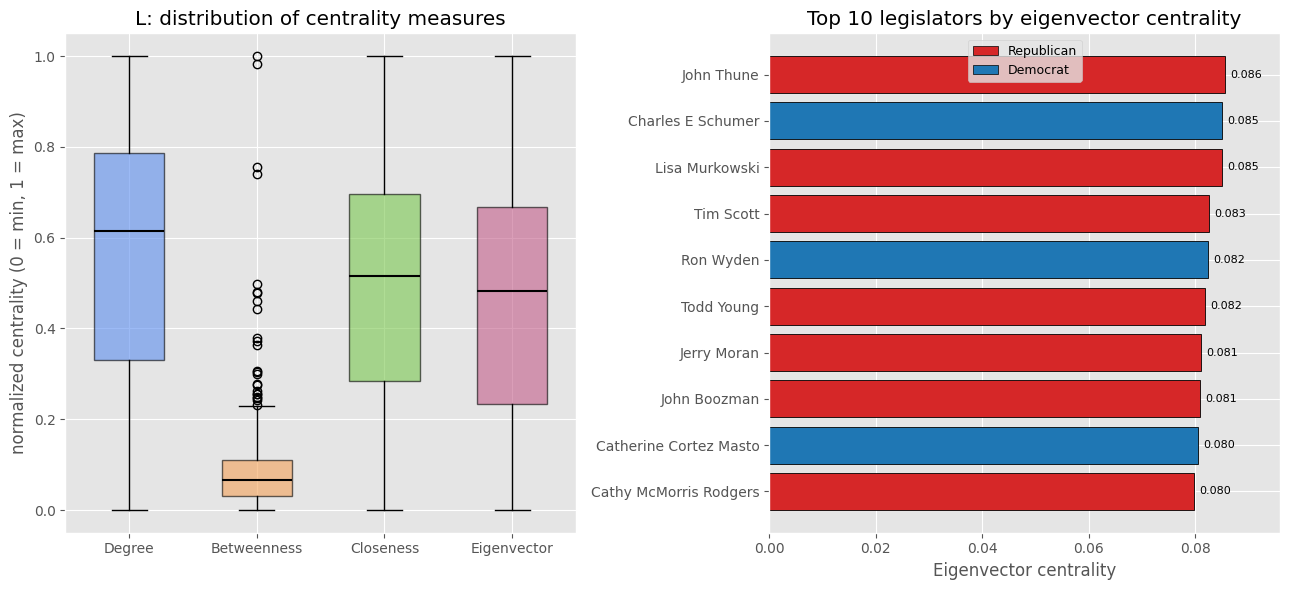

In [11]:
# Build centrality.png: comparison + top-10 eigenvector bar chart
from matplotlib.patches import Patch

top10 = df_L.nlargest(10, 'eig_c').iloc[::-1]   # reverse so highest is at top of barh

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# (Left) Boxplot comparison of the 4 centrality measures, normalized to [0,1]
norm = lambda x: (x - x.min()) / (x.max() - x.min() + 1e-12)
metrics = {
    'Degree':      norm(df_L['deg_c']),
    'Betweenness': norm(df_L['btw_c']),
    'Closeness':   norm(df_L['clo_c']),
    'Eigenvector': norm(df_L['eig_c']),
}
positions = np.arange(len(metrics))
parts = axes[0].boxplot(list(metrics.values()), positions=positions,
                         widths=0.55, patch_artist=True,
                         medianprops=dict(color='black', linewidth=1.5))
colors = ['#5b8def', '#f4a259', '#7ac74f', '#c25d8a']
for patch, c in zip(parts['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6); patch.set_edgecolor('black')
axes[0].set_xticks(positions); axes[0].set_xticklabels(list(metrics.keys()))
axes[0].set_ylabel('normalized centrality (0 = min, 1 = max)')
axes[0].set_title('L: distribution of centrality measures')

# (Right) Eigenvector top-10 bar chart, colored by party
party_colors = {'R': '#d62728', 'D': '#1f77b4', 'I': '#7f7f7f'}
bar_colors = [party_colors.get(p, '#aaaaaa') for p in top10['party']]
labels = [str(lbl).replace('(D)','').replace('(R)','').replace('(I)','').strip()
          for lbl in top10['name']]
y_pos = np.arange(len(top10))

axes[1].barh(y_pos, top10['eig_c'].values, color=bar_colors,
             edgecolor='black', linewidth=0.6)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(labels, fontsize=10)
axes[1].set_xlabel('Eigenvector centrality')
axes[1].set_title('Top 10 legislators by eigenvector centrality')

# Numeric labels at the end of each bar
for i, v in enumerate(top10['eig_c'].values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
axes[1].set_xlim(0, top10['eig_c'].max() * 1.12)

# Party legend
legend_elems = [Patch(facecolor=party_colors['R'], edgecolor='black', label='Republican'),
                Patch(facecolor=party_colors['D'], edgecolor='black', label='Democrat')]
axes[1].legend(handles=legend_elems, loc='upper center', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('centrality.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Community detection

> **Research question:** Do Communities of legislators emerge and correspond to political alignments?

I used NetworkX's greedy modularity maximization (Clauset–Newman–Moore) on the legislator projection `L`, sweeping the resolution parameter like in Lab 4. I then compared detected communities to the legislators' real party labels.

In [12]:
# Run modularity-based community detection on L
L_c, comms = find_communities(L, attr_name='community', resolution=1.0, weight='weight')
print(f"Found {len(comms)} communities at resolution=1.0")
for i, c in enumerate(comms):
    print(f"  community {i:2d}: {len(c):>4} legislators")


Found 2 communities at resolution=1.0
  community  0:  256 legislators
  community  1:  243 legislators


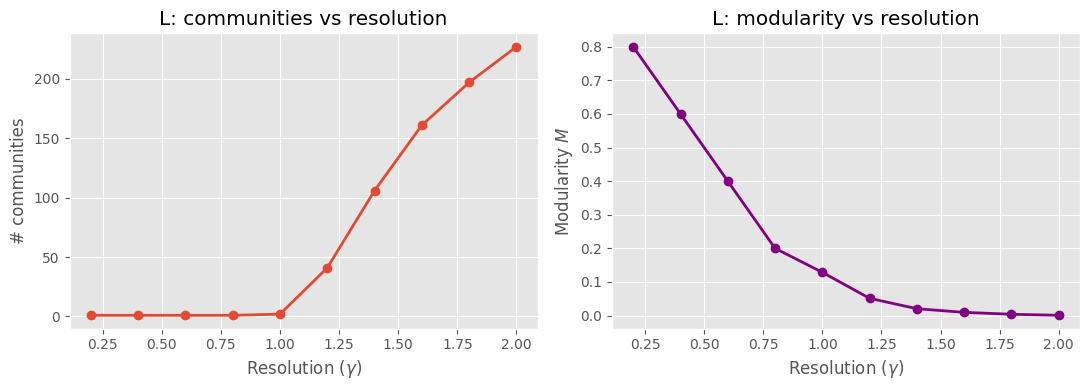

In [13]:
# Resolution sweep number of communities & modularity vs gamma
resolutions = np.arange(0.2, 2.1, 0.2)
n_comms_list = []
mod_list = []

for res in resolutions:
    L_c, comms_r = find_communities(L, attr_name=f'c_r={res:.1f}',
                                    resolution=res, weight='weight')
    n_comms_list.append(len(comms_r))
    mod_list.append(nx.community.modularity(L, comms_r,
                                            resolution=res, weight='weight'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(resolutions, n_comms_list, linewidth=2, marker='o')
axes[0].set_xlabel(r'Resolution ($\gamma$)'); axes[0].set_ylabel('# communities')
axes[0].set_title('L: communities vs resolution')

axes[1].plot(resolutions, mod_list, linewidth=2, color='purple', marker='o')
axes[1].set_xlabel(r'Resolution ($\gamma$)'); axes[1].set_ylabel('Modularity $M$')
axes[1].set_title('L: modularity vs resolution')

plt.tight_layout(); plt.show()


In [14]:
# Compare detected communities at gamma=1 to real party labels
L_c, comms_default = find_communities(L, attr_name='community',
                                      resolution=1.0, weight='weight')

# Build (party, community) contingency table
rows = []
for n in L.nodes:
    rows.append({'party': L.nodes[n].get('party',''),
                 'community': L.nodes[n]['community']})
ct = pd.crosstab(pd.DataFrame(rows)['party'], pd.DataFrame(rows)['community'])
print("Contingency: party vs detected community")
print(ct)

# How "purely partisan" is each community?
purity = (ct.max(axis=0) / ct.sum(axis=0))
print("\nDominant-party purity per community (1.0 = perfectly homogeneous):")
print(purity.round(3).to_string())
print(f"\nWeighted-mean purity: {(purity * ct.sum(axis=0) / ct.sum().sum()).sum():.3f}")


Contingency: party vs detected community
community    0    1
party              
D            8  241
R          248    2

Dominant-party purity per community (1.0 = perfectly homogeneous):
community
0    0.969
1    0.992

Weighted-mean purity: 0.980


# 5. Assortativity and attribute correlations

> Do legislators preferentially share industries with peers of the *same* party / chamber / state? Is the network degree-assortative or degree-disassortative?

I mirrored the analysis from Lab 3.

In [15]:
# Degree assortativity
print("Degree Pearson correlation (Newman's r):")
print(f"  L: r = {nx.degree_pearson_correlation_coefficient(L, weight='weight'):.4f}")
print(f"  I: r = {nx.degree_pearson_correlation_coefficient(I, weight='weight'):.4f}")

Degree Pearson correlation (Newman's r):
  L: r = -0.2756
  I: r = -0.3787


In [16]:
# Attribute assortativity on L (categorical)
for attr in ['party', 'chamber', 'state', 'gender']:
    if all(attr in L.nodes[n] for n in L.nodes):
        r = nx.attribute_assortativity_coefficient(L, attr)
        print(f"L attribute assortativity, {attr:>8}:  r = {r:.4f}")

# Numeric assortativity on ideology (DW-NOMINATE dim1).
# Only count nodes with ideology data (has_ideology=1).
L_ideo = L.subgraph([n for n,d in L.nodes(data=True) if d.get('has_ideology')==1]).copy()
if L_ideo.number_of_edges() > 0:
    r = nx.numeric_assortativity_coefficient(L_ideo, 'ideology')
    print(f"L numeric assortativity,   ideology:  r = {r:.4f}  "
          f"({L_ideo.number_of_nodes()} nodes with ideology data)")

# Sector assortativity on I
for attr in ['sector']:
    if all(attr in I.nodes[n] for n in I.nodes):
        r = nx.attribute_assortativity_coefficient(I, attr)
        print(f"I attribute assortativity, {attr:>8}:  r = {r:.4f}")


L attribute assortativity,    party:  r = 0.2300
L attribute assortativity,  chamber:  r = 0.0159
L attribute assortativity,    state:  r = 0.0030
L attribute assortativity,   gender:  r = 0.0244
L numeric assortativity,   ideology:  r = 0.2292  (461 nodes with ideology data)
I attribute assortativity,   sector:  r = 0.0177


# 6. Spreading phenomena (SIS / SIR)

> How susceptible is this network to influence / information / talking-point spreading? What is the epidemic threshold, and how does it compare to the natural spreading rate of an idea introduced by a single industry-aligned legislator?

The SIS model is reused from Lab 5. The "pathogen" here can be interpreted as a piece of industry framing or a bill stance that spreads between legislators along edges of `L`(legislators who share funding sources are more likely to influence each other).

In [17]:
# SIS / SIR models code adapted from Lab 5

def sis_model(g, infection_rate=0.1, recovery_rate=0.1, tmax=200, initial_node=None):
    nx.set_node_attributes(g, "healthy", name='state')
    if initial_node is None:
        u_0 = np.random.choice(list(g.nodes))
    else:
        u_0 = initial_node
    g.nodes[u_0]['state'] = "infected"
    infected = {u_0}
    history = []
    for t in range(1, tmax):
        to_infect, to_recover = set(), set()
        for u in infected:
            for v in g.neighbors(u):
                if g.nodes[v]['state'] == 'infected':
                    continue
                if np.random.random() < infection_rate:
                    to_infect.add(v)
            if np.random.random() < recovery_rate:
                to_recover.add(u)
        for v in to_infect:
            g.nodes[v]['state'] = "infected"; infected.add(v)
        for v in to_recover:
            g.nodes[v]['state'] = "healthy"; infected.discard(v)
        history.append(len(infected)/len(g))
    return g, history


def sir_model(g, infection_rate=0.1, recovery_rate=0.1, tmax=200, initial_node=None):
    nx.set_node_attributes(g, "healthy", name='state')
    if initial_node is None:
        u_0 = np.random.choice(list(g.nodes))
    else:
        u_0 = initial_node
    g.nodes[u_0]['state'] = "infected"
    infected = {u_0}
    history_i, history_r = [], []
    n_recovered = 0
    for t in range(1, tmax):
        to_infect, to_recover = set(), set()
        for u in infected:
            for v in g.neighbors(u):
                if g.nodes[v]['state'] != 'healthy':
                    continue
                if np.random.random() < infection_rate:
                    to_infect.add(v)
            if np.random.random() < recovery_rate:
                to_recover.add(u)
        for v in to_infect:
            g.nodes[v]['state'] = "infected"; infected.add(v)
        for v in to_recover:
            g.nodes[v]['state'] = "recovered"; infected.discard(v); n_recovered += 1
        history_i.append(len(infected)/len(g))
        history_r.append(n_recovered/len(g))
    return g, history_i, history_r


In [18]:
# Compute the epidemic threshold for L (legislators)
k_avg = get_average_degree(L)
k2    = get_second_moment_of_degree(L)
lam_c = k_avg / k2
print(f"L: <k>={k_avg:.2f}, <k^2>={k2:.2f}, epidemic threshold lambda_c = {lam_c:.4f}")

L: <k>=253.72, <k^2>=81992.07, epidemic threshold lambda_c = 0.0031


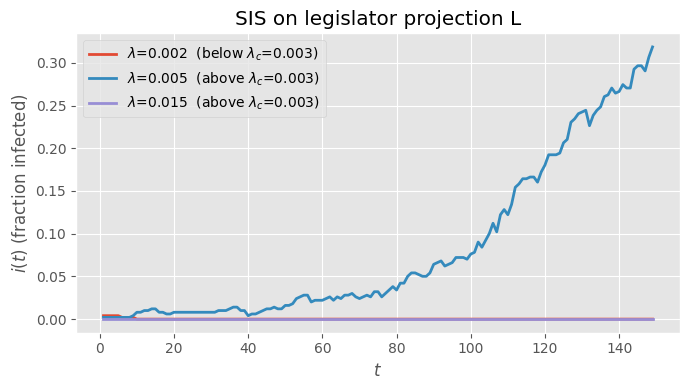

In [19]:
# Run SIS at three spreading rates: below, near, and above threshold
mu = 0.1
beta_list = [0.5*lam_c*mu, 1.5*lam_c*mu, 5.0*lam_c*mu]

tmax = 150
plt.figure(figsize=(7,4))
for beta in beta_list:
    L_run = L.copy()
    _, hist = sis_model(L_run, infection_rate=beta, recovery_rate=mu, tmax=tmax)
    lam = beta/mu
    plt.plot(range(1, tmax), hist, linewidth=2,
             label=fr'$\lambda$={lam:.3f}  ({"above" if lam>lam_c else "below"} $\lambda_c$={lam_c:.3f})')
plt.xlabel('$t$'); plt.ylabel('$i(t)$ (fraction infected)')
plt.title('SIS on legislator projection L')
plt.legend(); plt.tight_layout(); plt.show()

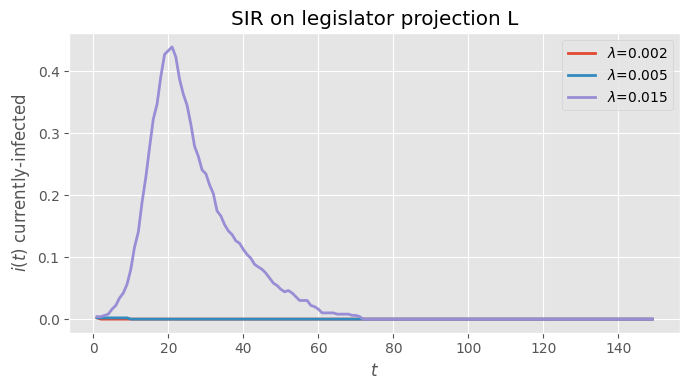

In [20]:
# Run SIR at the same rates
plt.figure(figsize=(7,4))
for beta in beta_list:
    L_run = L.copy()
    _, hist_i, hist_r = sir_model(L_run, infection_rate=beta, recovery_rate=mu, tmax=tmax)
    lam = beta/mu
    plt.plot(range(1, tmax), hist_i, linewidth=2,
             label=fr'$\lambda$={lam:.3f}')
plt.xlabel('$t$'); plt.ylabel('$i(t)$ currently-infected')
plt.title('SIR on legislator projection L')
plt.legend(); plt.tight_layout(); plt.show()
